In [1]:
from metacountregressor.solution import ObjectiveFunction
from metacountregressor.metaheuristics import differential_evolution
from metacountregressor.helperprocess import results_printer
import numpy as np
import pandas as pd

df = pd.read_csv('Comb.csv') #How do I choose the location of the data file?
df = pd.read_csv('https://raw.githubusercontent.com/zahern/data/main/synth.csv')
# define the count that you're interested in
y = df['Y'] # Frequency of crashes 
X = df

# Offset is already in the column___
#X['Offset'] = np.log1p(X['AADT']) # Explicitley define how to offset the data, no offset otherwise 
X['Offset']= X['na1']

# Drop Y, selected offset term and ID as there are no panels
X = df.drop(columns=['Y'])
#some example argument, these are defualt so the following line is just for claritity
arguments = {'algorithm': 'de', 'test_percentage': 0.2, 'test_complexity': 4, 'instance_number':0, '_distributions': ['normal'], 'model_type': [[1]], '_max_time': 60}
# Fit the model with metacountregressor
obj_fun = ObjectiveFunction(X, y, **arguments)
#replace with other metaheuristics if desired
arguments_de = {'_pop_size':4}
results = differential_evolution(obj_fun, **arguments_de)
results_printer(results, arguments['algorithm'], int(arguments['is_multi']))

Estimating as Panel Data...
the pop size is 4
dominate soltuion at specification test: 1
--------------------------------------------------------------------------------
The given estimates may not be reliable
--------------------------------------------------------------------------------
Log-Likelihood:  -3031.83156100842
--------------------------------------------------------------------------------
bic: 6122.69
--------------------------------------------------------------------------------
MSE: 655375.78
+----------------------------+-----+--------+----------+----------+------------+
|           Effect           | tau | Coeff  | Std. Err | z-values | Prob |z|>Z |
+============================+=====+========+==========+==========+============+
| const                      | no  | -29.50 |   0.29   |  -50.00  | 0.00***    |
+----------------------------+-----+--------+----------+----------+------------+
| X1                         | no  |  0.39  |   0.21   |   1.84   | 0.07.      

KeyError: 'is_multi'

results_printer(results, arguments['algorithm'], 1)

Elapsed time: 0:02:03.398748
Pareto Solutions: [{'aic': 2311.26922939972, 'bic': 2360.669059573771, 'MAE': 9.842269163065195, 'MSE': 9.842269163065195, 'layout': [1, 0, 0, 0, 3, 5, 5, 2, 1, 'triangular', 'normal', 'normal', 'triangular', 'normal', 'triangular', 'normal', 'triangular', 'ln_normal', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 0], 'sol_num': 3, 'num_parm': 9, 'pval_exceed': 2, 'pval_percentage': 0.2222222222222222, 'loglik': -1146.63461469986, 'simple': 'f_rp_p', 'fixed_fit': ['const', 'na5'], 'rdm_fit': ['na4'], 'rdm_cor_fit': ['na1'], 'zi_fit': None, 'pvalues': array([2.50344341e-02, 5.33308297e-01, 5.31487225e-01, 4.61196551e-03,
       7.75628212e-03, 1.59854422e-14, 5.25298673e-03, 9.15847215e-01,
       2.56623972e-08])}, {'aic': 2409.447831536752, 'bic': 2464.2254206190305, 'MAE': 5.65758611973707, 'MSE': 5.65758611973707, 'layout': [1, 5, 3, 0, 1, 1, 5, 5, 0, 'ln_normal', 'tn_normal', 'uniform', 'uniform', 'tn_normal', 'tn_normal', 'normal', 'uniform', '

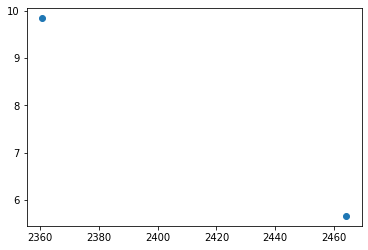

In [2]:
results_printer(results, arguments['algorithm'], 1)